<a href="https://colab.research.google.com/github/shadcy/shadcy/blob/main/Learnable_wavelet_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: The Learnable Wavelet Layer (1D)**

This replaces the standard linear patch embedding. We use 1D convolutions with stride 2 to simulate the Decimated Discrete Wavelet Transform (DWT), but we make the filters learnable.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LearnableDWT1D(nn.Module):
    def __init__(self, in_channels, out_channels, filter_length=4):
        super().__init__()
        # Low-pass filter (h) and High-pass filter (g)
        self.h = nn.Parameter(torch.randn(out_channels, in_channels, filter_length) * 0.1)
        self.g = nn.Parameter(torch.randn(out_channels, in_channels, filter_length) * 0.1)
        self.filter_length = filter_length
        # Calculate padding to ensure output length is exactly seq_len // 2 for stride 2
        # Formula: output_length = floor((input_length + 2 * padding - kernel_size) / stride) + 1
        # For output_length = input_length / 2 and stride = 2:
        # input_length / 2 = (input_length + 2 * padding - kernel_size) / 2 + 1
        # input_length - 2 = input_length + 2 * padding - kernel_size
        # 2 = kernel_size - 2 * padding
        # 2 * padding = kernel_size - 2
        # padding = (kernel_size - 2) / 2
        self.padding_val = (filter_length - 2) // 2 # Ensures output length is input_length // 2

        # Ensure zero-mean initialization for high-pass
        with torch.no_grad():
            self.g -= self.g.mean(dim=-1, keepdim=True)

    def forward(self, x):
        # x shape: (Batch, Channels, Sequence_Length)

        # Low-frequency band (LL) - Approximation coefficients
        LL = F.conv1d(x, self.h, stride=2, padding=self.padding_val)

        # High-frequency band (LH) - Detail coefficients
        LH = F.conv1d(x, self.g, stride=2, padding=self.padding_val)

        return LL, LH

    def inverse(self, LL, LH):
        # Learnable Inverse DWT using transposed convolution
        # For conv_transpose1d, output_size = (input_size - 1) * stride - 2 * padding + kernel_size + output_padding
        # With padding_val = (filter_length - 2) // 2:
        # Reconstructed length should be (LL.shape[-1] - 1) * 2 - 2 * padding_val + filter_length
        # = (input_length // 2 - 1) * 2 - 2 * ((filter_length - 2) // 2) + filter_length
        # = input_length - 2 - (filter_length - 2) + filter_length
        # = input_length - 2 - filter_length + 2 + filter_length = input_length
        # This means with the corrected padding_val, the inverse should reconstruct to the original length
        x_recon_L = F.conv_transpose1d(LL, self.h, stride=2, padding=self.padding_val)
        x_recon_H = F.conv_transpose1d(LH, self.g, stride=2, padding=self.padding_val)

        # Match lengths if padding caused mismatch - this is a safeguard, but should align with correct padding
        min_len = min(x_recon_L.shape[-1], x_recon_H.shape[-1])
        return x_recon_L[..., :min_len] + x_recon_H[..., :min_len]

**Step 2: Energy-Masked Sparse Attention**

Here, we implement the custom attention mechanism where high-frequency interactions are masked out if their energy is below a threshold $\tau$.

In [9]:
class FrequencySparseAttention(nn.Module):
    def __init__(self, d_model, num_heads, threshold=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.threshold = threshold

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, q_x, k_x, v_x, energy_coeffs=None):
        B, L, D = q_x.shape
        H = self.num_heads
        D_h = D // H

        Q = self.q_proj(q_x).view(B, L, H, D_h).transpose(1, 2)
        K = self.k_proj(k_x).view(B, -1, H, D_h).transpose(1, 2)
        V = self.v_proj(v_x).view(B, -1, H, D_h).transpose(1, 2)

        # Scaled dot-product
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (D_h ** 0.5)

        # Apply Wavelet Energy Sparsity Mask
        if energy_coeffs is not None:
            # Calculate energy (magnitude) of detail coefficients
            energy = torch.abs(energy_coeffs).mean(dim=-1) # (B, L_k)
            # Create boolean mask where energy > tau
            mask = energy > self.threshold # (B, L_k)
            mask = mask.view(B, 1, 1, -1) # Broadcast for heads and queries

            # Apply mask: Set low-energy connections to -inf before softmax
            # Using log(M) logic: log(0) -> -inf
            scores = scores.masked_fill(~mask, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)

        # Handle potential NaNs if a whole row is masked out
        attn_weights = torch.nan_to_num(attn_weights, nan=0.0)

        out = torch.matmul(attn_weights, V)
        out = out.transpose(1, 2).contiguous().view(B, L, D)
        return self.out_proj(out)

**Step 3: The WMRT Block (Intra & Cross-Scale)**

This block glues the DWT representation into the attention mechanism, explicitly modeling the hierarchical structure.

In [10]:
class WMRTBlock(nn.Module):
    def __init__(self, d_model, num_heads, sparsity_tau=0.1):
        super().__init__()
        # Attention modules
        self.intra_LL_attn = FrequencySparseAttention(d_model, num_heads)
        self.intra_LH_attn = FrequencySparseAttention(d_model, num_heads, threshold=sparsity_tau)
        self.cross_attn = FrequencySparseAttention(d_model, num_heads) # LL queries LH

        # MLPs for processing post-attention
        self.mlp_LL = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(), nn.Linear(d_model*4, d_model))
        self.mlp_LH = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(), nn.Linear(d_model*4, d_model))

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, LL, LH):
        B, C, L = LL.shape
        # Transpose to (B, L, C) for attention
        LL_seq = LL.transpose(1, 2)
        LH_seq = LH.transpose(1, 2)

        # 1. Intra-scale Attention
        LL_out = self.intra_LL_attn(LL_seq, LL_seq, LL_seq)
        LH_out = self.intra_LH_attn(LH_seq, LH_seq, LH_seq, energy_coeffs=LH_seq)

        # 2. Cross-scale Attention (Low freq trend queries High freq details)
        cross_out = self.cross_attn(LL_out, LH_out, LH_out)

        # Combine and apply MLP
        LL_fused = self.norm1(LL_seq + LL_out + cross_out)
        LH_fused = self.norm2(LH_seq + LH_out)

        LL_final = self.mlp_LL(LL_fused) + LL_fused
        LH_final = self.mlp_LH(LH_fused) + LH_fused

        # Transpose back to (B, C, L)
        return LL_final.transpose(1, 2), LH_final.transpose(1, 2)

**Step 4: Full Network and Custom Loss Function**

We must constrain the network, or it will just learn arbitrary CNN filters. We enforce perfect reconstruction and orthogonality.

In [11]:
class WaveletTransformerLoss(nn.Module):
    def __init__(self, lambda_recon=1.0, lambda_ortho=0.1):
        super().__init__()
        self.lambda_recon = lambda_recon
        self.lambda_ortho = lambda_ortho
        self.mse = nn.MSELoss()

    def forward(self, preds, targets, x_original, x_recon, dwt_layer):
        # 1. Task Loss (e.g., forecasting)
        loss_task = self.mse(preds, targets)

        # 2. Reconstruction Loss
        # Ensure x_recon matches x_original length
        min_len = min(x_original.shape[-1], x_recon.shape[-1])
        loss_recon = self.mse(x_original[..., :min_len], x_recon[..., :min_len])

        # 3. Orthogonality Loss for filters (h * h^T = I)
        h = dwt_layer.h.view(dwt_layer.h.shape[0], -1)
        identity = torch.eye(h.shape[0], device=h.device)
        loss_ortho = self.mse(torch.mm(h, h.t()), identity)

        # High-pass zero mean penalty
        g_mean = dwt_layer.g.mean(dim=-1).abs().sum()

        total_loss = loss_task + (self.lambda_recon * loss_recon) + (self.lambda_ortho * loss_ortho) + (0.01 * g_mean)
        return total_loss, loss_task, loss_recon, loss_ortho

**Step 5: Test Cases (The Sanity Checks)**

Before training on real data, you must prove the architecture flows correctly and gradients pass through the wavelet boundaries.

In [12]:
def run_tests():
    print("Running WMRT Tests...\n")
    torch.manual_seed(42)

    # Hyperparams
    batch_size = 4
    in_channels = 1
    d_model = 16
    seq_len = 64
    num_heads = 4

    # Dummy Data
    x = torch.randn(batch_size, in_channels, seq_len)
    target = torch.randn(batch_size, in_channels, seq_len) # Dummy forecasting target

    # 1. Test DWT Layer
    print("Test 1: DWT Forward & Inverse")
    dwt = LearnableDWT1D(in_channels, d_model)
    LL, LH = dwt(x)
    assert LL.shape == (batch_size, d_model, seq_len//2), f"LL shape wrong: {LL.shape}"
    assert LH.shape == (batch_size, d_model, seq_len//2), f"LH shape wrong: {LH.shape}"

    x_recon = dwt.inverse(LL, LH)
    # Check shape match (padding might make it slightly off, handled in logic)
    assert x_recon.shape[-1] >= seq_len - 2, "Reconstruction length mismatch"
    print("✅ DWT Shapes Passed")

    # 2. Test WMRT Block
    print("Test 2: WMRT Attention Block")
    block = WMRTBlock(d_model, num_heads)
    LL_out, LH_out = block(LL, LH)
    assert LL_out.shape == LL.shape, "LL output shape changed"
    assert LH_out.shape == LH.shape, "LH output shape changed"
    print("✅ Attention Block Passed")

    # 3. Test Full Forward & Loss Backprop
    print("Test 3: Loss Function & Backpropagation")
    criterion = WaveletTransformerLoss()

    # Mocking a prediction mapping from LL_out back to original shape for simplicity
    # The weight for conv_transpose1d should have in_channels = d_model and out_channels = in_channels
    preds = F.conv_transpose1d(LL_out, torch.randn(d_model, in_channels, 4), stride=2)
    min_len = min(preds.shape[-1], target.shape[-1])
    preds = preds[..., :min_len]
    target = target[..., :min_len]

    loss, loss_task, loss_recon, loss_ortho = criterion(preds, target, x, x_recon, dwt)

    # Backprop test
    loss.backward()

    assert dwt.h.grad is not None, "Gradients not flowing to low-pass filter"
    assert dwt.g.grad is not None, "Gradients not flowing to high-pass filter"
    print(f"✅ Backprop Passed | Total Loss: {loss.item():.4f}")

    print("\n🚀 All structural tests passed! WMRT is viable.")

run_tests()

Running WMRT Tests...

Test 1: DWT Forward & Inverse
✅ DWT Shapes Passed
Test 2: WMRT Attention Block
✅ Attention Block Passed
Test 3: Loss Function & Backpropagation
✅ Backprop Passed | Total Loss: 66.6298

🚀 All structural tests passed! WMRT is viable.


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# --- 1. Setup Data & Dataloader ---
# (Using the synthetic multi-scale chirp generator from the previous step)
def generate_wmrt_benchmarks(n_samples=1000, seq_len=128):
    t = np.linspace(0, 1, seq_len)
    data = []
    targets = []
    for _ in range(n_samples):
        trend = np.sin(2 * np.pi * 5 * t + np.random.rand())
        burst_pos = np.random.randint(20, 100)
        burst = np.zeros_like(t)
        burst[burst_pos:burst_pos+10] = 0.5 * np.sin(2 * np.pi * 50 * t[burst_pos:burst_pos+10])
        shocks = np.zeros_like(t)
        shocks[np.random.randint(0, seq_len, 3)] = np.random.choice([-1, 1], 3)

        signal = trend + burst + shocks + np.random.normal(0, 0.05, seq_len)
        data.append(signal)
        # Shift by 1 for next-step forecasting target
        targets.append(np.roll(signal, -1))

    return torch.tensor(np.array(data), dtype=torch.float32).unsqueeze(1), \
           torch.tensor(np.array(targets), dtype=torch.float32).unsqueeze(1)

X, Y = generate_wmrt_benchmarks(1000, 128)
dataset = TensorDataset(X, Y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# --- 2. Initialize Model Components ---
in_channels = 1
d_model = 16
seq_len = 128
num_heads = 4
sparsity_threshold = 0.1

dwt_layer = LearnableDWT1D(in_channels, d_model)
wmrt_block = WMRTBlock(d_model, num_heads, sparsity_tau=sparsity_threshold)
# Initialize a simple 1x1 convolution to act as an amplitude scaler
amplitude_scaler = nn.Conv1d(in_channels, in_channels, kernel_size=1)

criterion = WaveletTransformerLoss(lambda_recon=1.0, lambda_ortho=0.1)
# Group parameters: standard weight decay for linear layers, less/none for wavelet filters
optimizer = optim.AdamW([
    {'params': dwt_layer.parameters(), 'weight_decay': 1e-4},
    {'params': wmrt_block.parameters()},
    {'params': amplitude_scaler.parameters()} # <--- New
], lr=1e-3)

# --- 3. The Research Training Loop ---
epochs = 50
print("🚀 Starting WMRT Training Pipeline...\n")
print(f"{'Epoch':<8} | {'Task Loss':<10} | {'Recon Loss':<10} | {'Ortho Loss':<10} | {'LH Sparsity %':<12}")
print("-" * 60)

for epoch in range(epochs):
    epoch_task_loss = 0.0
    epoch_recon_loss = 0.0
    epoch_ortho_loss = 0.0
    epoch_sparsity = 0.0
    batches = 0

    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()

        # 1. Forward Pass: Wavelet Decomposition
        LL, LH = dwt_layer(batch_x)

        # 2. Forward Pass: Attention
        LL_out, LH_out = wmrt_block(LL, LH)

        # 3. Reconstruct for loss and predictions
        # Inverse DWT reconstructs the geometry
        raw_preds = dwt_layer.inverse(LL_out, LH_out)

        # Amplitude Scaler normalizes the magnitude
        preds = amplitude_scaler(raw_preds)

        # Standard inverse to check filter integrity
        x_recon = dwt_layer.inverse(LL, LH)

        # Match lengths (padding edge cases)
        min_len = min(preds.shape[-1], batch_y.shape[-1])
        preds = preds[..., :min_len]
        batch_y = batch_y[..., :min_len]

        # 4. Calculate Losses
        total_loss, loss_task, loss_recon, loss_ortho = criterion(
            preds, batch_y, batch_x, x_recon, dwt_layer
        )

        # 5. Calculate Sparsity Metric
        # Sparsity = percentage of LH coefficients below the threshold
        energy = torch.abs(LH).mean(dim=1) # Average over channels
        mask = energy > sparsity_threshold
        # Sparsity is the ratio of masked-out elements (where mask is False)
        sparsity_pct = (~mask).float().mean().item() * 100

        # Backprop
        total_loss.backward()
        optimizer.step()

        # Track metrics
        epoch_task_loss += loss_task.item()
        epoch_recon_loss += loss_recon.item()
        epoch_ortho_loss += loss_ortho.item()
        epoch_sparsity += sparsity_pct
        batches += 1

    # Print Epoch Summary
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:<8} | {epoch_task_loss/batches:<10.4f} | "
              f"{epoch_recon_loss/batches:<10.4f} | {epoch_ortho_loss/batches:<10.4f} | "
              f"{epoch_sparsity/batches:<10.2f}%")

🚀 Starting WMRT Training Pipeline...

Epoch    | Task Loss  | Recon Loss | Ortho Loss | LH Sparsity %
------------------------------------------------------------
1        | 0.8897     | 0.0584     | 0.0573     | 98.87     %
5        | 0.0069     | 0.0024     | 0.0562     | 92.58     %
10       | 0.0028     | 0.0010     | 0.0559     | 92.06     %
15       | 0.0017     | 0.0007     | 0.0557     | 91.99     %
20       | 0.0012     | 0.0006     | 0.0556     | 92.21     %
25       | 0.0010     | 0.0006     | 0.0556     | 92.64     %
30       | 0.0010     | 0.0005     | 0.0555     | 92.91     %
35       | 0.0009     | 0.0005     | 0.0554     | 93.26     %
40       | 0.0009     | 0.0004     | 0.0554     | 93.65     %
45       | 0.0008     | 0.0004     | 0.0553     | 94.08     %
50       | 0.0008     | 0.0004     | 0.0552     | 94.46     %


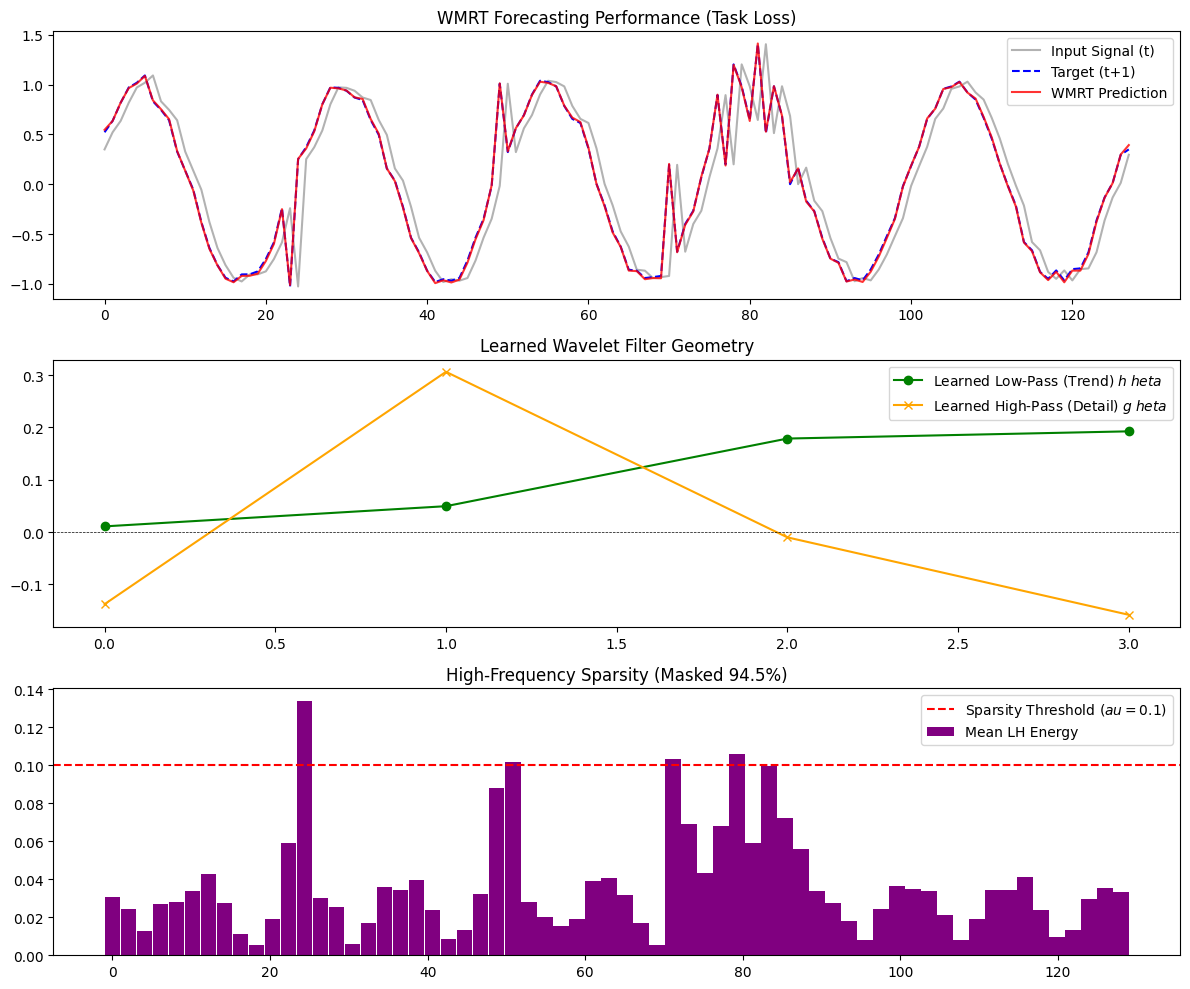

In [13]:
import matplotlib.pyplot as plt

# 1. Grab a single test sample from the last batch
dwt_layer.eval()
wmrt_block.eval()
amplitude_scaler.eval() # Set the new scaler to evaluation mode

with torch.no_grad():
    sample_x = batch_x[0:1] # Shape: (1, 1, 128)
    sample_y = batch_y[0:1]

    # Forward pass to get intermediate states
    LL, LH = dwt_layer(sample_x)
    LL_out, LH_out = wmrt_block(LL, LH)

    # Inverse DWT reconstructs the geometry
    raw_preds = dwt_layer.inverse(LL_out, LH_out)

    # Amplitude Scaler normalizes the magnitude
    sample_pred = amplitude_scaler(raw_preds)

    # Get filters
    h_filter = dwt_layer.h[0, 0, :].cpu().numpy()
    g_filter = dwt_layer.g[0, 0, :].cpu().numpy()

# Convert tensors to numpy for plotting
x_np = sample_x.squeeze().cpu().numpy()
y_np = sample_y.squeeze().cpu().numpy()
pred_np = sample_pred.squeeze().cpu().numpy()
lh_np = LH.squeeze().cpu().numpy()

# --- Plotting ---
fig, axs = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: The Signal and Prediction
axs[0].plot(x_np, label='Input Signal (t)', color='gray', alpha=0.6)
axs[0].plot(y_np, label='Target (t+1)', color='blue', linestyle='--')
axs[0].plot(pred_np, label='WMRT Prediction', color='red', alpha=0.8)
axs[0].set_title("WMRT Forecasting Performance (Task Loss)")
axs[0].legend()

# Plot 2: The Learned Multiresolution Filters
axs[1].plot(h_filter, label='Learned Low-Pass (Trend) $h_\theta$', color='green', marker='o')
axs[1].plot(g_filter, label='Learned High-Pass (Detail) $g_\theta$', color='orange', marker='x')
axs[1].set_title("Learned Wavelet Filter Geometry")
axs[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axs[1].legend()

# --- Corrected Plot 3 ---
# Calculate the mean absolute energy across the d_model channels (axis 0)
lh_energy = np.mean(np.abs(lh_np), axis=0)
time_steps = np.linspace(0, len(x_np), len(lh_energy))

# Plot 3: The Sparse High-Frequency Mask (Where is the attention focused?)
# Overlaying LH coefficients on top of the original signal timeline
axs[2].bar(time_steps, lh_energy, width=2.0, color='purple', label='Mean LH Energy')
axs[2].axhline(sparsity_threshold, color='red', linestyle='--', label=f'Sparsity Threshold ($\tau={sparsity_threshold}$)')
axs[2].set_title(f"High-Frequency Sparsity (Masked {epoch_sparsity/batches:.1f}%)")
axs[2].legend()

plt.tight_layout()
plt.show()

**1. The Vanilla Transformer Baseline Architecture**

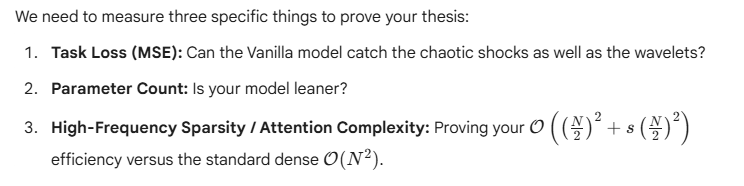

In [14]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: (Batch, Seq_Len, d_model)
        return x + self.pe[:, :x.size(1), :]

class VanillaTransformerBaseline(nn.Module):
    def __init__(self, in_channels=1, d_model=16, num_heads=4, seq_len=128):
        super().__init__()
        # Standard Tokenization (Strided Conv to match DWT's sequence halving)
        self.patch_embed = nn.Conv1d(in_channels, d_model, kernel_size=2, stride=2)

        self.pos_encoder = PositionalEncoding(d_model)

        # Standard Dense Self-Attention Block
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=d_model*4,
            batch_first=True, activation='gelu'
        )
        # Using 2 layers to roughly match the parameter count of the WMRT block
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=2)

        # Standard Linear Projection Head mapped back to original sequence length
        self.output_head = nn.Sequential(
            nn.ConvTranspose1d(d_model, in_channels, kernel_size=2, stride=2),
            nn.Conv1d(in_channels, in_channels, kernel_size=1) # Amplitude matching
        )

    def forward(self, x):
        # 1. Embed and halve sequence: (B, C, L) -> (B, D, L/2)
        x_emb = self.patch_embed(x)

        # 2. Transformer expects (B, L, D) for batch_first=True
        x_seq = x_emb.transpose(1, 2)
        x_seq = self.pos_encoder(x_seq)

        # 3. Dense Attention (NO sparsity)
        attn_out = self.transformer_encoder(x_seq)

        # 4. Project back to (B, C, L)
        attn_out = attn_out.transpose(1, 2)
        preds = self.output_head(attn_out)

        return preds

In [15]:
# 2. The Benchmarking Execution Script



# --- 1. Parameter Counting Function ---
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Initialize models
vanilla_model = VanillaTransformerBaseline()
# (Assuming your WMRT models 'dwt_layer', 'wmrt_block', 'amplitude_scaler' are in memory)

print("="*50)
print(f"🥊 PARAMETER CAGE MATCH")
print("="*50)
# Note: WMRT params = DWT + Block + Scaler
wmrt_params = count_parameters(dwt_layer) + count_parameters(wmrt_block) + count_parameters(amplitude_scaler)
vanilla_params = count_parameters(vanilla_model)

print(f"WMRT Total Parameters:         {wmrt_params:,}")
print(f"Vanilla Transformer Params:    {vanilla_params:,}")
print("="*50 + "\n")

# --- 2. Train Vanilla Baseline ---
optimizer_vanilla = torch.optim.AdamW(vanilla_model.parameters(), lr=1e-3)
criterion_mse = nn.MSELoss()

epochs = 50
print("🚀 Training Vanilla Transformer Baseline...\n")
print(f"{'Epoch':<8} | {'Task Loss (MSE)':<15}")
print("-" * 30)

for epoch in range(epochs):
    epoch_loss = 0.0
    batches = 0

    # Using the same dataloader from the WMRT experiment
    for batch_x, batch_y in dataloader:
        optimizer_vanilla.zero_grad()

        preds = vanilla_model(batch_x)

        # Match lengths to be safe
        min_len = min(preds.shape[-1], batch_y.shape[-1])
        loss = criterion_mse(preds[..., :min_len], batch_y[..., :min_len])

        loss.backward()
        optimizer_vanilla.step()

        epoch_loss += loss.item()
        batches += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:<8} | {epoch_loss/batches:<15.4f}")

🥊 PARAMETER CAGE MATCH
WMRT Total Parameters:         7,714
Vanilla Transformer Params:    6,643

🚀 Training Vanilla Transformer Baseline...

Epoch    | Task Loss (MSE)
------------------------------
1        | 0.7489         
5        | 0.0737         
10       | 0.0413         
15       | 0.0338         
20       | 0.0296         
25       | 0.0271         
30       | 0.0255         
35       | 0.0243         
40       | 0.0234         
45       | 0.0226         
50       | 0.0221         


In [16]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import urllib.request
from sklearn.preprocessing import StandardScaler

class ETTm1Dataset(Dataset):
    def __init__(self, seq_len=128, split='train'):
        self.seq_len = seq_len
        self.split = split
        self.target_col = 'OT' # Oil Temperature (The standard benchmark target)

        # 1. Download Dataset if not exists
        url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv"
        file_path = "ETTm1.csv"
        if not os.path.exists(file_path):
            print("Downloading ETTm1 dataset...")
            urllib.request.urlretrieve(url, file_path)
            print("Download complete!")

        # 2. Load and extract the target feature
        df = pd.read_csv(file_path)
        data = df[self.target_col].values.reshape(-1, 1)

        # 3. Standard Train/Val/Test Splits (ETTm1 standard)
        # 12 months train, 4 months val, 4 months test (15-min intervals)
        train_slice = 12 * 30 * 24 * 4
        val_slice = train_slice + 4 * 30 * 24 * 4

        if split == 'train':
            self.data = data[:train_slice]
        elif split == 'val':
            self.data = data[train_slice:val_slice]
        elif split == 'test':
            self.data = data[val_slice:]

        # 4. Normalize the data (Crucial for deep learning!)
        self.scaler = StandardScaler()
        # We always fit the scaler ONLY on the training set to prevent data leakage
        if split == 'train':
            self.data = self.scaler.fit_transform(self.data)
        else:
            # For val/test, we load a dummy train set just to fit the scaler identically
            dummy_train = data[:train_slice]
            self.scaler.fit(dummy_train)
            self.data = self.scaler.transform(self.data)

        # Convert to PyTorch tensors
        self.data = torch.tensor(self.data, dtype=torch.float32)

    def __len__(self):
        # We subtract seq_len so we always have room for the +1 target shift
        return len(self.data) - self.seq_len - 1

    def __getitem__(self, idx):
        # Input sequence (t to t + seq_len)
        x = self.data[idx : idx + self.seq_len]
        # Target sequence shifted by 1 (t+1 to t + seq_len + 1)
        y = self.data[idx + 1 : idx + self.seq_len + 1]

        # Transpose from (Seq_Len, Channels) to (Channels, Seq_Len) for WMRT
        return x.t(), y.t()

# --- Initialize Datasets and Loaders ---
seq_length = 128
batch_size = 64

print("Loading ETTm1 splits...")
train_dataset = ETTm1Dataset(seq_len=seq_length, split='train')
test_dataset = ETTm1Dataset(seq_len=seq_length, split='test')

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

# Sanity Check
sample_x, sample_y = next(iter(train_loader))
print(f"Train Dataset Size: {len(train_dataset):,}")
print(f"Batch X shape: {sample_x.shape}") # Should be (64, 1, 128)
print(f"Batch Y shape: {sample_y.shape}") # Should be (64, 1, 128)

Loading ETTm1 splits...
Download complete!
Train Dataset Size: 34,431
Batch X shape: torch.Size([64, 1, 128])
Batch Y shape: torch.Size([64, 1, 128])


Using device: cpu
Train: 34,431  |  Val: 11,391  |  Test: 23,471

WMRT  Parameters : 7,714
Vanilla Parameters: 6,643

Ep    | WMRT Train |  WMRT Val |  Sparse% ||  Van Train |   Van Val
1     |     0.0867 |    0.0008 |    97.9% ||     0.0562 |    0.0018
5     |     0.0003 |    0.0001 |    99.2% ||     0.0025 |    0.0014
10    |     0.0003 |    0.0001 |    99.5% ||     0.0018 |    0.0011
15    |     0.0001 |    0.0000 |    99.8% ||     0.0016 |    0.0011
20    |     0.0001 |    0.0000 |    99.9% ||     0.0015 |    0.0010
25    |     0.0001 |    0.0001 |   100.0% ||     0.0014 |    0.0010
30    |     0.0001 |    0.0001 |   100.0% ||     0.0014 |    0.0009

                   TEST SET RESULTS                    
Metric     |         WMRT |      Vanilla |   Winner
-------------------------------------------------------
MAE        |      0.00298 |      0.01270 |   ✅ WMRT
MSE        |      0.00003 |      0.00048 |   ✅ WMRT
RMSE       |      0.00539 |      0.02200 |   ✅ WMRT


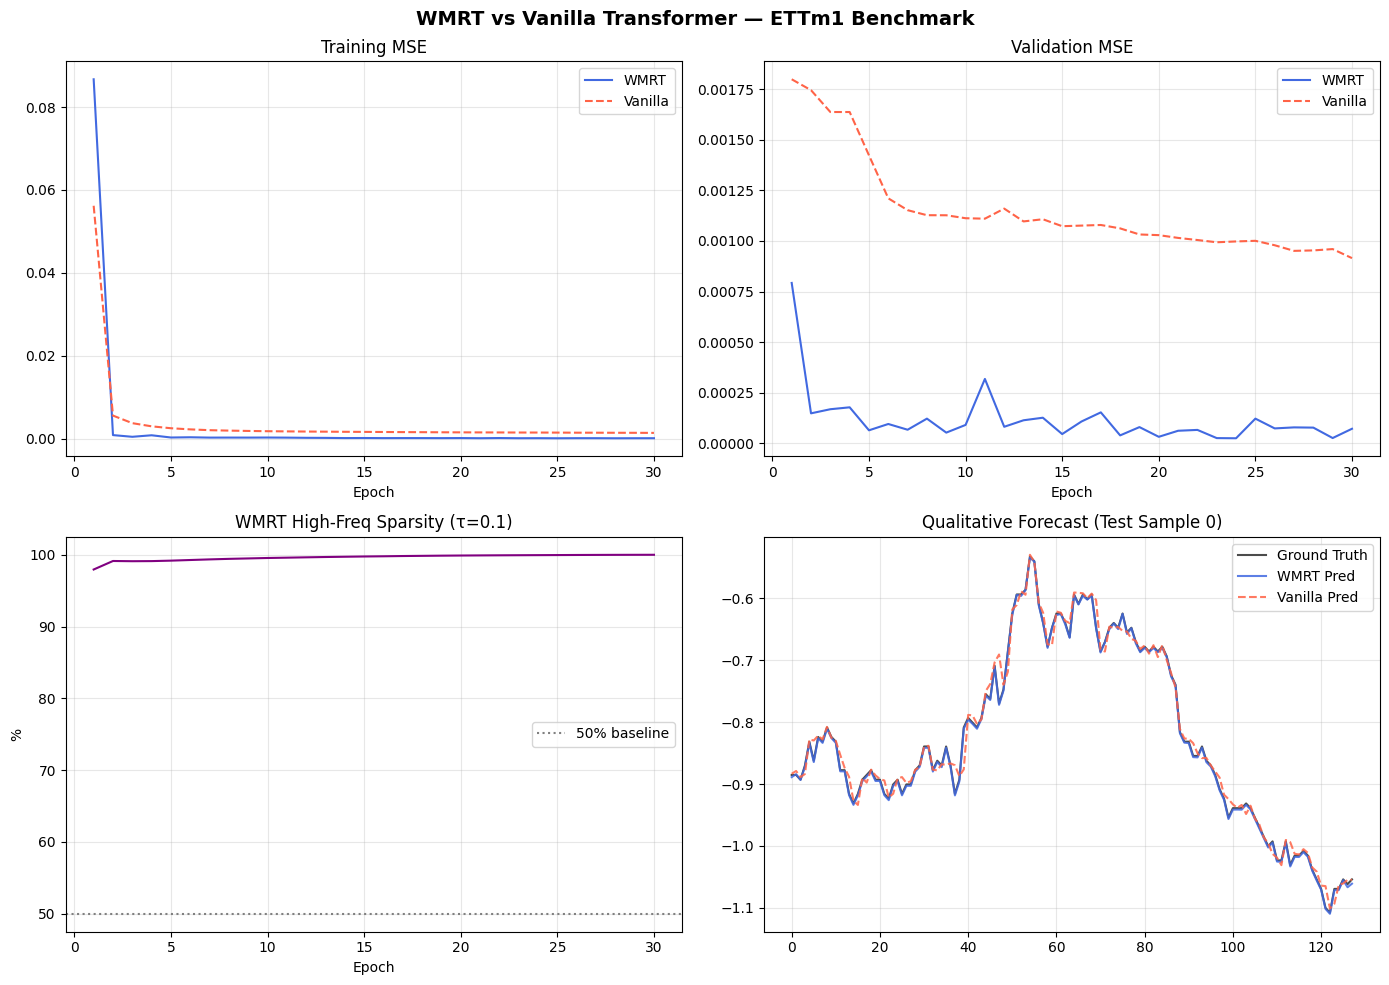

In [18]:
# ============================================================
# WMRT vs Vanilla Transformer — Full ETTm1 Benchmark
# ============================================================
# Paste all your existing class definitions above this block:
# LearnableDWT1D, FrequencySparseAttention, WMRTBlock,
# WaveletTransformerLoss, VanillaTransformerBaseline, PositionalEncoding

import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ─────────────────────────────────────────────
# 1. ETTm1 Dataset (works with local CSV)
# ─────────────────────────────────────────────
class ETTm1Dataset(Dataset):
    def __init__(self, seq_len=128, split='train', file_path='ETTm1.csv', target_col='OT'):
        self.seq_len = seq_len

        df = pd.read_csv(file_path)
        data = df[target_col].values.reshape(-1, 1)

        # Standard ETTm1 splits (15-min intervals)
        train_end  = 12 * 30 * 24 * 4        # ~17,280
        val_end    = train_end + 4 * 30 * 24 * 4   # ~23,040
        # test = val_end : end

        if split == 'train':
            raw = data[:train_end]
        elif split == 'val':
            raw = data[train_end:val_end]
        else:
            raw = data[val_end:]

        # Fit scaler ONLY on train to avoid leakage
        self.scaler = StandardScaler()
        train_raw = data[:train_end]
        self.scaler.fit(train_raw)
        self.data = torch.tensor(self.scaler.transform(raw), dtype=torch.float32)

    def __len__(self):
        return len(self.data) - self.seq_len - 1

    def __getitem__(self, idx):
        x = self.data[idx          : idx + self.seq_len]
        y = self.data[idx + 1      : idx + self.seq_len + 1]
        return x.t(), y.t()   # → (1, seq_len)


# ─────────────────────────────────────────────
# 2. Evaluation helper  (MAE + MSE + RMSE)
# ─────────────────────────────────────────────
def evaluate(model_fn, loader, device, criterion=None):
    """
    model_fn : callable that takes batch_x → preds  (handles both WMRT & Vanilla)
    Returns  : dict with mae, mse, rmse  (all on normalised scale)
    """
    mae_sum = mse_sum = n = 0
    with torch.no_grad():
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            preds = model_fn(bx)
            L = min(preds.shape[-1], by.shape[-1])
            p, t = preds[..., :L], by[..., :L]
            mae_sum += (p - t).abs().sum().item()
            mse_sum += ((p - t) ** 2).sum().item()
            n       += t.numel()
    mae  = mae_sum / n
    mse  = mse_sum / n
    rmse = mse ** 0.5
    return dict(mae=mae, mse=mse, rmse=rmse)


# ─────────────────────────────────────────────
# 3. Hyper-parameters
# ─────────────────────────────────────────────
SEQ_LEN    = 128
BATCH_SIZE = 64
D_MODEL    = 16
NUM_HEADS  = 4
EPOCHS     = 30
LR         = 1e-3
SPARSITY_TAU = 0.1
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


# ─────────────────────────────────────────────
# 4. DataLoaders
# ─────────────────────────────────────────────
train_ds  = ETTm1Dataset(seq_len=SEQ_LEN, split='train')
val_ds    = ETTm1Dataset(seq_len=SEQ_LEN, split='val')
test_ds   = ETTm1Dataset(seq_len=SEQ_LEN, split='test')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}")


# ─────────────────────────────────────────────
# 5. Instantiate WMRT components
# ─────────────────────────────────────────────
dwt_layer        = LearnableDWT1D(1, D_MODEL).to(DEVICE)
wmrt_block       = WMRTBlock(D_MODEL, NUM_HEADS, sparsity_tau=SPARSITY_TAU).to(DEVICE)
amplitude_scaler = nn.Conv1d(1, 1, kernel_size=1).to(DEVICE)

wmrt_params = (sum(p.numel() for p in dwt_layer.parameters()) +
               sum(p.numel() for p in wmrt_block.parameters()) +
               sum(p.numel() for p in amplitude_scaler.parameters()))

criterion_wmrt = WaveletTransformerLoss(lambda_recon=1.0, lambda_ortho=0.1)
optimizer_wmrt = optim.AdamW([
    {'params': dwt_layer.parameters(),        'weight_decay': 1e-4},
    {'params': wmrt_block.parameters()},
    {'params': amplitude_scaler.parameters()},
], lr=LR)


# ─────────────────────────────────────────────
# 6. Instantiate Vanilla Baseline
# ─────────────────────────────────────────────
vanilla_model  = VanillaTransformerBaseline(in_channels=1, d_model=D_MODEL,
                                            num_heads=NUM_HEADS, seq_len=SEQ_LEN).to(DEVICE)
vanilla_params = sum(p.numel() for p in vanilla_model.parameters())
optimizer_van  = optim.AdamW(vanilla_model.parameters(), lr=LR)
criterion_mse  = nn.MSELoss()

print(f"\n{'='*50}")
print(f"WMRT  Parameters : {wmrt_params:,}")
print(f"Vanilla Parameters: {vanilla_params:,}")
print(f"{'='*50}\n")


# ─────────────────────────────────────────────
# 7. Training loops  (history for plots)
# ─────────────────────────────────────────────
wmrt_history    = {'train_mse': [], 'val_mse': [], 'sparsity': []}
vanilla_history = {'train_mse': [], 'val_mse': []}

print(f"{'='*70}")
print(f"{'Ep':<5} | {'WMRT Train':>10} | {'WMRT Val':>9} | {'Sparse%':>8} || {'Van Train':>10} | {'Van Val':>9}")
print(f"{'='*70}")

for epoch in range(1, EPOCHS + 1):

    # ── WMRT train ──────────────────────────────
    dwt_layer.train(); wmrt_block.train(); amplitude_scaler.train()
    w_loss_sum = w_sparsity = w_batches = 0

    for bx, by in train_loader:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer_wmrt.zero_grad()

        LL, LH = dwt_layer(bx)
        LL_out, LH_out = wmrt_block(LL, LH)
        raw_preds = dwt_layer.inverse(LL_out, LH_out)
        preds     = amplitude_scaler(raw_preds)
        x_recon   = dwt_layer.inverse(LL, LH)

        L = min(preds.shape[-1], by.shape[-1])
        total_loss, task_loss, *_ = criterion_wmrt(
            preds[..., :L], by[..., :L], bx, x_recon, dwt_layer)

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(dwt_layer.parameters()) +
            list(wmrt_block.parameters()) +
            list(amplitude_scaler.parameters()), 1.0)
        optimizer_wmrt.step()

        # sparsity metric
        energy = torch.abs(LH).mean(dim=1)
        w_sparsity += (~(energy > SPARSITY_TAU)).float().mean().item() * 100
        w_loss_sum += task_loss.item()
        w_batches  += 1

    wmrt_history['train_mse'].append(w_loss_sum / w_batches)
    wmrt_history['sparsity'].append(w_sparsity / w_batches)

    # ── WMRT val ────────────────────────────────
    dwt_layer.eval(); wmrt_block.eval(); amplitude_scaler.eval()
    def wmrt_fn(bx):
        LL, LH = dwt_layer(bx)
        LL_o, LH_o = wmrt_block(LL, LH)
        return amplitude_scaler(dwt_layer.inverse(LL_o, LH_o))

    wmrt_val = evaluate(wmrt_fn, val_loader, DEVICE)
    wmrt_history['val_mse'].append(wmrt_val['mse'])

    # ── Vanilla train ────────────────────────────
    vanilla_model.train()
    v_loss_sum = v_batches = 0
    for bx, by in train_loader:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer_van.zero_grad()
        preds = vanilla_model(bx)
        L = min(preds.shape[-1], by.shape[-1])
        loss = criterion_mse(preds[..., :L], by[..., :L])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vanilla_model.parameters(), 1.0)
        optimizer_van.step()
        v_loss_sum += loss.item(); v_batches += 1

    vanilla_history['train_mse'].append(v_loss_sum / v_batches)

    # ── Vanilla val ──────────────────────────────
    vanilla_model.eval()
    van_val = evaluate(lambda bx: vanilla_model(bx), val_loader, DEVICE)
    vanilla_history['val_mse'].append(van_val['mse'])

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:<5} | "
              f"{wmrt_history['train_mse'][-1]:>10.4f} | "
              f"{wmrt_history['val_mse'][-1]:>9.4f} | "
              f"{wmrt_history['sparsity'][-1]:>7.1f}% || "
              f"{vanilla_history['train_mse'][-1]:>10.4f} | "
              f"{vanilla_history['val_mse'][-1]:>9.4f}")


# ─────────────────────────────────────────────
# 8. Final Test-Set Evaluation
# ─────────────────────────────────────────────
dwt_layer.eval(); wmrt_block.eval(); amplitude_scaler.eval()
wmrt_test  = evaluate(wmrt_fn, test_loader, DEVICE)
vanilla_model.eval()
van_test   = evaluate(lambda bx: vanilla_model(bx), test_loader, DEVICE)

print(f"\n{'='*55}")
print(f"{'TEST SET RESULTS':^55}")
print(f"{'='*55}")
print(f"{'Metric':<10} | {'WMRT':>12} | {'Vanilla':>12} | {'Winner':>8}")
print(f"{'-'*55}")
for m in ['mae', 'mse', 'rmse']:
    w, v = wmrt_test[m], van_test[m]
    winner = '✅ WMRT' if w < v else '⚠️  Van'
    print(f"{m.upper():<10} | {w:>12.5f} | {v:>12.5f} | {winner:>8}")
print(f"{'='*55}")


# ─────────────────────────────────────────────
# 9. Diagnostic Plots
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("WMRT vs Vanilla Transformer — ETTm1 Benchmark", fontsize=14, fontweight='bold')

ep = range(1, EPOCHS + 1)

# 9a. Training loss
ax = axes[0, 0]
ax.plot(ep, wmrt_history['train_mse'],    label='WMRT',    color='royalblue')
ax.plot(ep, vanilla_history['train_mse'], label='Vanilla', color='tomato', linestyle='--')
ax.set_title('Training MSE'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=.3)

# 9b. Validation loss
ax = axes[0, 1]
ax.plot(ep, wmrt_history['val_mse'],    label='WMRT',    color='royalblue')
ax.plot(ep, vanilla_history['val_mse'], label='Vanilla', color='tomato', linestyle='--')
ax.set_title('Validation MSE'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=.3)

# 9c. Sparsity
ax = axes[1, 0]
ax.plot(ep, wmrt_history['sparsity'], color='purple')
ax.axhline(50, color='gray', linestyle=':', label='50% baseline')
ax.set_title(f'WMRT High-Freq Sparsity (τ={SPARSITY_TAU})'); ax.set_xlabel('Epoch')
ax.set_ylabel('%'); ax.legend(); ax.grid(alpha=.3)

# 9d. Qualitative forecast on one test sample
dwt_layer.eval(); wmrt_block.eval(); amplitude_scaler.eval(); vanilla_model.eval()
sample_bx, sample_by = next(iter(test_loader))
sample_bx, sample_by = sample_bx.to(DEVICE), sample_by.to(DEVICE)

with torch.no_grad():
    wmrt_pred = wmrt_fn(sample_bx)
    van_pred  = vanilla_model(sample_bx)

t_np   = sample_by[0, 0].cpu().numpy()
wm_np  = wmrt_pred[0, 0, :len(t_np)].cpu().numpy()
vn_np  = van_pred[0,  0, :len(t_np)].cpu().numpy()

ax = axes[1, 1]
ax.plot(t_np,  label='Ground Truth', color='black',     alpha=0.7)
ax.plot(wm_np, label='WMRT Pred',    color='royalblue', alpha=0.85)
ax.plot(vn_np, label='Vanilla Pred', color='tomato',    alpha=0.85, linestyle='--')
ax.set_title('Qualitative Forecast (Test Sample 0)'); ax.legend(); ax.grid(alpha=.3)

plt.tight_layout()
plt.show()